In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [ ]:
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

In [ ]:
TARGET_COL = "pm2_5 (μg/m³)"

# keep the target and all predictor columns, but remove explicit timestamp/time fields from the feature set
dataset = dataset.set_index("timestamp")
dataset.sort_index(inplace=True)
dataset = dataset.asfreq("h")
dataset = dataset.drop(columns=["time"], errors="ignore")

FEATURE_COLS = [col for col in dataset.columns]
N_FEATURES = len(FEATURE_COLS)
TARGET_SCALER_IDX = FEATURE_COLS.index(TARGET_COL)

INPUT_WINDOW = 24 * 3
OUTPUT_WINDOW = 24
BATCH_SIZE = 64

train_raw = dataset.loc[:"2024-12-31 23:00:00", FEATURE_COLS].copy()
test_raw = dataset.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00", FEATURE_COLS].copy()

scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw), columns=FEATURE_COLS, index=train_raw.index)
test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=FEATURE_COLS, index=test_raw.index)


def create_clock_anchored_sequences(df_scaled, feature_cols, target_col, input_w, output_w):
    X, Y = [], []
    feature_matrix = df_scaled[feature_cols].values
    target_vector = df_scaled[target_col].values

    for i in range(len(df_scaled) - input_w - output_w + 1):
        X.append(feature_matrix[i : i + input_w, :])
        Y.append(target_vector[i + input_w : i + input_w + output_w])

    return np.array(X), np.array(Y)

X_train, y_train = create_clock_anchored_sequences(train_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_clock_anchored_sequences(test_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)

In [ ]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
import torch
import torch.nn as nn

class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super(TransformerLSTMModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        x = self.input_projection(src)
        x = x + self.pos_encoder[:, :src.size(1), :]
        x = self.dropout(x)
        transformer_out = self.transformer_encoder(x)
        lstm_out, (hn, cn) = self.lstm(transformer_out)
        out = lstm_out[:, -1, :]
        predictions = self.fc(self.dropout(out))
        return predictions

In [ ]:
from pytorch_lightning.callbacks import Callback

class SimpleLossTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(train_loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

loss_tracker = SimpleLossTracker()

In [ ]:
def inverse_transform_target(scaled_data, scaler, target_idx, n_features):
    flat_data = scaled_data.flatten()
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, target_idx] = flat_data
    unscaled_dummy = scaler.inverse_transform(dummy)
    return unscaled_dummy[:, target_idx].reshape(scaled_data.shape)

In [ ]:
from sklearn.metrics import r2_score as sk_r2

def _run_inference(model, X_np, scaler, target_idx, n_features, device, batch_size=512):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32)
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            preds.append(model(X_t[i:i+batch_size].to(device)).cpu().numpy())
    p = inverse_transform_target(np.vstack(preds), scaler, target_idx, n_features)
    return p


def permutation_importance_timeseries(
    model, X_np, y_np_inv, feature_cols, scaler,
    target_idx, n_features, device,
    n_repeats=10, batch_size=512, seed=42
):
    rng = np.random.default_rng(seed)
    n_samples = X_np.shape[0]
    y_flat = y_np_inv.flatten()

    base_pred = _run_inference(model, X_np, scaler, target_idx, n_features, device, batch_size)
    baseline_mae = mean_absolute_error(y_flat, base_pred.flatten())
    baseline_r2  = sk_r2(y_flat, base_pred.flatten())
    print(f"Baseline  MAE={baseline_mae:.4f} μg/m³  R²={baseline_r2:.4f}")

    importances = {}
    for feat_idx, feat_name in enumerate(feature_cols):
        d_mae, d_r2 = [], []
        for _ in range(n_repeats):
            X_p = X_np.copy()
            idx = rng.permutation(n_samples)
            X_p[:, :, feat_idx] = X_p[idx, :, feat_idx]
            p = _run_inference(model, X_p, scaler, target_idx, n_features, device, batch_size)
            pf = p.flatten()
            d_mae.append(mean_absolute_error(y_flat, pf) - baseline_mae)
            d_r2.append(baseline_r2 - sk_r2(y_flat, pf))
        importances[feat_name] = {
            'mae_mean': float(np.mean(d_mae)), 'mae_std': float(np.std(d_mae)),
            'r2_mean':  float(np.mean(d_r2)),  'r2_std':  float(np.std(d_r2)),
        }
        print(f"  {feat_name:40s}  ΔMAE={importances[feat_name]['mae_mean']:+.4f}±{importances[feat_name]['mae_std']:.4f}  "
              f"ΔR²={importances[feat_name]['r2_mean']:+.4f}±{importances[feat_name]['r2_std']:.4f}")

    return baseline_mae, baseline_r2, importances


y_test_inv = inverse_transform_target(y_test, scaler, TARGET_SCALER_IDX, N_FEATURES)
baseline_mae, baseline_r2, importances = permutation_importance_timeseries(
    model=final_model, X_np=X_test.copy(), y_np_inv=y_test_inv,
    feature_cols=FEATURE_COLS, scaler=scaler,
    target_idx=TARGET_SCALER_IDX, n_features=N_FEATURES,
    device=DEVICE, n_repeats=10, batch_size=512, seed=42
)

In [ ]:
sorted_by_mae = sorted(importances.items(), key=lambda x: x[1]['mae_mean'], reverse=True)
feat_names = [f for f, _ in sorted_by_mae]
mae_means  = np.array([v['mae_mean'] for _, v in sorted_by_mae])
mae_stds   = np.array([v['mae_std']  for _, v in sorted_by_mae])
r2_means   = np.array([v['r2_mean']  for _, v in sorted_by_mae])
r2_stds    = np.array([v['r2_std']   for _, v in sorted_by_mae])

fig, axes = plt.subplots(1, 2, figsize=(14, 0.5 * len(feat_names) + 2), sharey=True)

for ax, vals, stds, xlabel, title in [
    (axes[0], mae_means, mae_stds, 'ΔMAE (μg/m³)', 'MAE importance\n(higher = more important)'),
    (axes[1], r2_means,  r2_stds,  'ΔR²',           'R² importance\n(higher = more important)'),
]:
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in vals]
    ax.barh(feat_names, vals, xerr=stds, color=colors, edgecolor='black',
            linewidth=0.5, error_kw=dict(elinewidth=1.2, capsize=4))
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.invert_yaxis()

fig.suptitle(
    f'Permutation Feature Importance — PM2.5 Forecasting\n'
    f'baseline MAE={baseline_mae:.3f} μg/m³  R²={baseline_r2:.4f}  (10 repeats)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRanking by ΔMAE (most → least important):')
for rank, (fn, v) in enumerate(sorted_by_mae, 1):
    print(f"  {rank:2d}. {fn:40s}  ΔMAE={v['mae_mean']:+.4f}  ΔR²={v['r2_mean']:+.4f}")

In [ ]:
import torch.optim as optim

def _build_loaders(feats):
    Xtr, ytr = create_clock_anchored_sequences(train_scaled[feats], feats, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
    Xte, yte = create_clock_anchored_sequences(test_scaled[feats],  feats, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
    mk = lambda X, y, shuf: DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=shuf)
    return mk(Xtr, ytr, True), mk(Xte, yte, False), Xte, yte


def _train_eval(feats, epochs=60):
    tr_loader, te_loader, Xte, yte = _build_loaders(feats)
    n_feat = len(feats)
    scaler_idx = feats.index(TARGET_COL)
    m = TransformerLSTMModel(
        input_dim=n_feat, seq_len=INPUT_WINDOW, d_model=32, nhead=4,
        num_transformer_layers=1, hidden_dim=256, num_lstm_layers=4,
        dropout=0.3403, output_dim=OUTPUT_WINDOW
    ).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=1.1967e-05)
    crit = nn.MSELoss()
    for epoch in range(epochs):
        m.train()
        for bx, by in tr_loader:
            bx, by = bx.to(DEVICE, non_blocking=True), by.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = crit(m(bx), by)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
    m.eval()
    preds = []
    with torch.no_grad():
        for bx, _ in te_loader:
            preds.append(m(bx.to(DEVICE)).cpu().numpy())
    p_inv = inverse_transform_target(
        np.vstack(preds), scaler,
        TARGET_SCALER_IDX, N_FEATURES
    )
    y_inv = inverse_transform_target(yte, scaler, TARGET_SCALER_IDX, N_FEATURES)
    yf, pf = y_inv.flatten(), p_inv.flatten()
    return mean_absolute_error(yf, pf), sk_r2(yf, pf)


positive_feats = [fn for fn, v in sorted_by_mae if v['mae_mean'] > 0]
print(f"Features with positive ΔMAE ({len(positive_feats)}): {positive_feats}")

results = []
for k in range(1, len(positive_feats) + 1):
    candidate = positive_feats[:k]
    if TARGET_COL not in candidate:
        candidate = [TARGET_COL] + [f for f in candidate if f != TARGET_COL]
    mae, r2 = _train_eval(candidate)
    results.append({'n': k, 'features': candidate.copy(), 'mae': mae, 'r2': r2})
    print(f"  top-{k:2d}  MAE={mae:.4f}  R²={r2:.4f}  {candidate}")

best = min(results, key=lambda x: x['mae'])
print(f"\nBest subset by MAE  → {len(best['features'])} features  MAE={best['mae']:.4f}  R²={best['r2']:.4f}")
print(f"Features: {best['features']}")
optimal_features = best['features']

In [ ]:
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

final_model = TransformerLSTMModel(
    input_dim=N_FEATURES, 
    seq_len=INPUT_WINDOW, 
    d_model=32, 
    nhead=4, 
    num_transformer_layers=1, 
    hidden_dim=256,  
    num_lstm_layers=4, 
    dropout=0.3403, 
    output_dim=OUTPUT_WINDOW
).to(DEVICE)

final_optimizer = optim.Adam(final_model.parameters(), lr=1.1967208840656558e-05)
criterion = nn.MSELoss()

hist_train = []
hist_val = []
FINAL_EPOCHS = 60

print(f"\nTraining final optimized model for {FINAL_EPOCHS} epochs...")
for epoch in range(FINAL_EPOCHS):
    final_model.train()
    epoch_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE, non_blocking=True)
        batch_y = batch_y.to(DEVICE, non_blocking=True)

        final_optimizer.zero_grad(set_to_none=True)
        predictions = final_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        
        nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        final_optimizer.step()
        
        epoch_train_loss += loss.item() * batch_x.size(0)

    total_train_loss = epoch_train_loss / len(train_loader.dataset)
    hist_train.append(total_train_loss)

    final_model.eval()
    epoch_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            val_predictions = final_model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            
            epoch_val_loss += val_loss.item() * batch_x.size(0)
            
    total_val_loss = epoch_val_loss / len(test_loader.dataset)
    hist_val.append(total_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | Train Loss (MSE): {total_train_loss:.6f} | Val Loss (MSE): {total_val_loss:.6f}")

print("\nEvaluating full-feature model and computing permutation importance...")
baseline_mae, importances = permutation_importance_timeseries(
    model=final_model,
    X_np=X_test.copy(),
    y_tensor=torch.tensor(y_test, dtype=torch.float32),
    feature_cols=FEATURE_COLS,
    scaler=scaler,
    target_idx=TARGET_SCALER_IDX,
    n_features=N_FEATURES,
    device=DEVICE,
    n_repeats=10,
    seed=42
)

selected_features = get_top_features(importances, top_n=10, min_delta=0.0)
print(f"\nSelected feature set ({len(selected_features)} features): {selected_features}")

selected_train_loader, selected_test_loader = build_feature_dataloaders(selected_features, batch_size=BATCH_SIZE)

selected_model = TransformerLSTMModel(
    input_dim=len(selected_features),
    seq_len=INPUT_WINDOW,
    d_model=32,
    nhead=4,
    num_transformer_layers=1,
    hidden_dim=256,
    num_lstm_layers=4,
    dropout=0.3403,
    output_dim=OUTPUT_WINDOW
).to(DEVICE)
selected_optimizer = optim.Adam(selected_model.parameters(), lr=1.1967208840656558e-05)

SELECTED_EPOCHS = 40
print(f"\nTraining selected-feature model for {SELECTED_EPOCHS} epochs...")
selected_hist_train, selected_hist_val = train_model(
    selected_model,
    selected_optimizer,
    selected_train_loader,
    selected_test_loader,
    criterion,
    DEVICE,
    epochs=SELECTED_EPOCHS,
    clip_norm=1.0,
    log_interval=10
)
print("\nSelected-feature model training complete.")



--- Best Hyperparameters Found ---
  d_model: 32
  nhead: 4
  num_transformer_layers: 1
  hidden_dim: 256
  num_lstm_layers: 4
  dropout: 0.3402839381977396
  lr: 1.1967208840656558e-05

Training final optimized model for 60 epochs...
Epoch 01/60 | Train Loss (MSE): 0.007311 | Val Loss (MSE): 0.013158
Epoch 10/60 | Train Loss (MSE): 0.003642 | Val Loss (MSE): 0.003722
Epoch 20/60 | Train Loss (MSE): 0.003298 | Val Loss (MSE): 0.003235
Epoch 30/60 | Train Loss (MSE): 0.003098 | Val Loss (MSE): 0.003549
Epoch 40/60 | Train Loss (MSE): 0.002948 | Val Loss (MSE): 0.002985
Epoch 50/60 | Train Loss (MSE): 0.002798 | Val Loss (MSE): 0.002805
Epoch 60/60 | Train Loss (MSE): 0.002679 | Val Loss (MSE): 0.002801


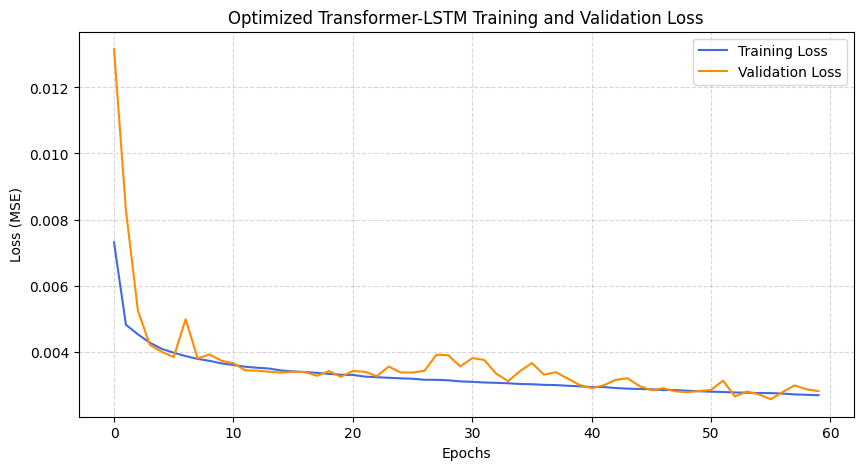

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(hist_train, label='Training Loss', color='royalblue')
plt.plot(hist_val, label='Validation Loss', color='darkorange')
plt.title('Optimized Transformer-LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

In [ ]:
final_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        
        preds = final_model(batch_x).cpu().numpy()
        actuals = batch_y.numpy()
        
        all_predictions.append(preds)
        all_ground_truth.append(actuals)

all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

true_predictions_all = inverse_transform_target(all_predictions, scaler, TARGET_SCALER_IDX, N_FEATURES)
true_ground_truth_all = inverse_transform_target(all_ground_truth, scaler, TARGET_SCALER_IDX, N_FEATURES)

global_mae = mean_absolute_error(true_ground_truth_all.flatten(), true_predictions_all.flatten())
global_rmse = np.sqrt(mean_squared_error(true_ground_truth_all.flatten(), true_predictions_all.flatten()))
global_r2 = sklearn_r2(true_ground_truth_all.flatten(), true_predictions_all.flatten())

ground_truth_mean = np.mean(true_ground_truth_all)
mae_percentage = (global_mae / ground_truth_mean)
rmse_percentage = (global_rmse / ground_truth_mean)

print(f"\n=== Final Transformer-LSTM Benchmark Results ===")
print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")


=== Final Transformer-LSTM Benchmark Results ===
Global R² Score     : 0.6219
Global MAE          : 2.9127 μg/m³
Global RMSE         : 3.9643 μg/m³
MAE% (Normalized)   : 0.31
RMSE% (Normalized)  : 0.42
